# Project 1 — Attention Visualizer

> **Transformer Mastery • Project Track**

This notebook is designed as an end-to-end, reproducible learning artifact: clear goals → implementation → experiments → diagnostics → conclusions.

In [1]:
import math, random, re, time
from collections import Counter
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

SEED = 32
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError as e:
    raise ImportError("Install Pytorch first") from e

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

PyTorch: 2.11.0+cpu
Device: cpu


## 1. Attention Visualizer

**Goal:** make the mechanics of scaled dot-product attention visible. We construct Q, K, V, compute scores, apply the √dₖ scaling, softmax the scores, and visualize the resulting attention matrix.

In [2]:
tokens = ["The", "cat", "sat", "on", "mat"]
d_k = 8
Q = torch.randn(len(tokens), d_k)
K = torch.randn(len(tokens), d_k)
V = torch.randn(len(tokens), d_k)

scores = Q @ K.T
scaled_scores = scores / math.sqrt(d_k)
weights = F.softmax(scaled_scores, dim=-1)

print("Attention weights shape:", tuple(weights.shape))
print("Each row sums to:", weights.sum(dim=-1).detach().numpy())


Attention weights shape: (5, 5)
Each row sums to: [1.0000001  0.99999994 1.         1.         1.        ]


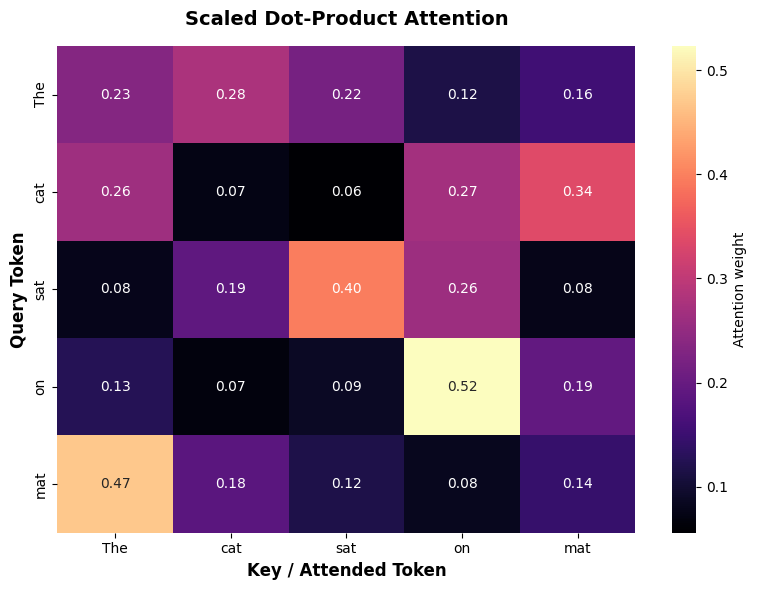

In [3]:
attn_matrix = weights.detach().numpy()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    attn_matrix,
    xticklabels=tokens,
    yticklabels=tokens,
    cmap="magma",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Attention weight"}
)

ax.set_xlabel("Key / Attended Token", fontsize=12, fontweight="bold")
ax.set_ylabel("Query Token", fontsize=12, fontweight="bold")
ax.set_title("Scaled Dot-Product Attention", fontsize=14, fontweight="bold", pad=15)

plt.tight_layout()
plt.show()

### Temperature / sharpness experiment

A useful mental model is that scaling the logits changes how concentrated the distribution becomes. Here we expose that effect directly.

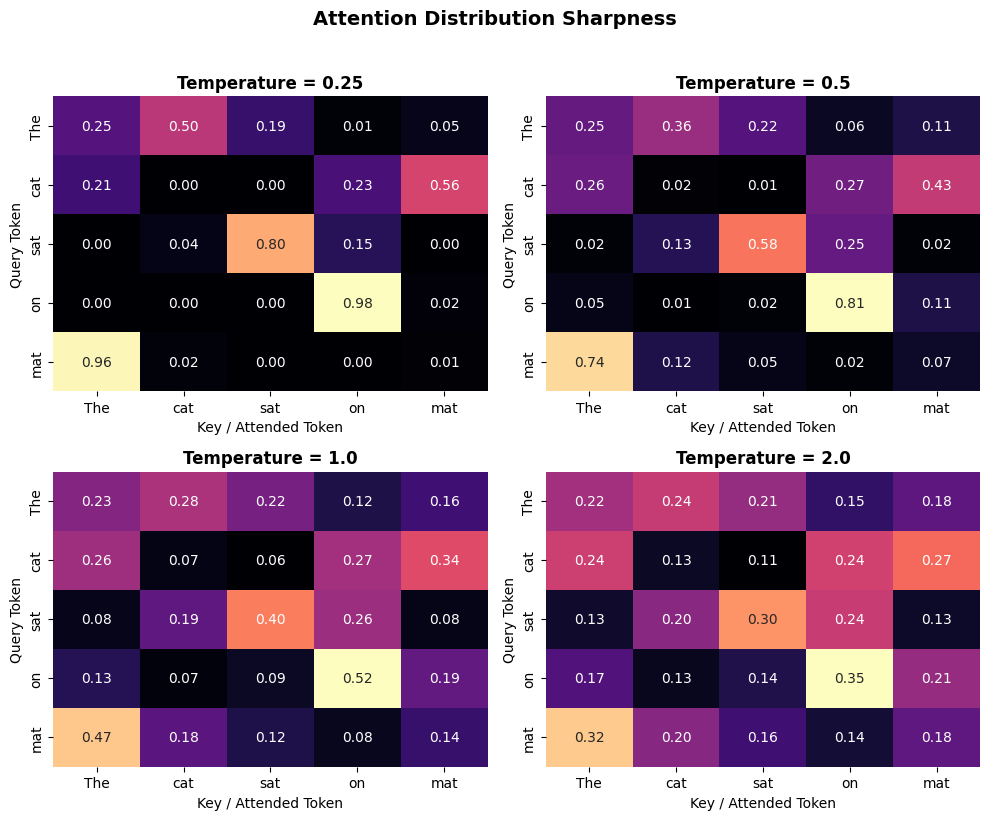

In [4]:
temperatures = [0.25, 0.5, 1.0, 2.0]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, t in zip(axes.ravel(), temperatures):
    w = F.softmax(scaled_scores / t, dim=-1).detach().numpy()
    sns.heatmap(
        w,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="magma",
        annot=True,
        fmt=".2f",
        cbar=False,
        ax=ax
    )
    ax.set_title(f"Temperature = {t}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Key / Attended Token")
    ax.set_ylabel("Query Token")

plt.suptitle("Attention Distribution Sharpness", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Causal masking

Autoregressive language models must not allow a token to attend to future tokens. The upper triangle is therefore replaced with −∞ before softmax.

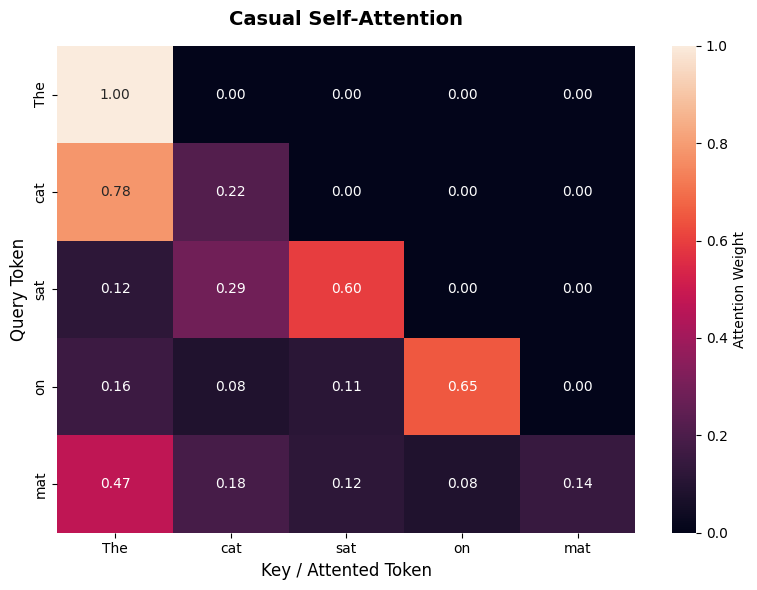

In [5]:
casual_mask    = torch.triu(torch.ones(len(tokens), len(tokens), dtype=torch.bool), diagonal=1)
masked_logits  = scaled_scores.masked_fill(casual_mask, float("-inf"))
casual_weights = F.softmax(masked_logits, dim=-1).detach().numpy()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    casual_weights,
    xticklabels=tokens,
    yticklabels=tokens,
    cmap="rocket",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Attention Weight"},
    ax=ax
)

ax.set_title("Casual Self-Attention", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Key / Attented Token", fontsize=12)
ax.set_ylabel("Query Token", fontsize=12)

plt.tight_layout()
plt.show()

assert torch.allclose(
    torch.triu(torch.tensor(casual_weights), diagonal=1),
    torch.zeros_like(torch.triu(torch.tensor(casual_weights), diagonal=1))
)